<a href="https://colab.research.google.com/github/Adidtiasmara/PCVK26_16_Firman/blob/main/Week5_16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**SEL IDENTITAS**

In [14]:
#===== SEL IDENTITAS - JANGAN DIHAPUS, HARUS SEL PERTAMA =====
import sys, platform, hashlib, datetime, zoneinfo
NAMA = 'Muhammad Firman Aditiasmara'
NIM = '244107020094'
N = int(NIM[-3:])
PARAM = {
'bins' : 2 ** ((N % 4) + 3),
'clip' : round(1.0 + (N % 5) * 0.5, 1),
'tile' : (N % 4) + 2,
'L' : 2 ** ((N % 3) + 1),
}
waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))
print('NAMA :', NAMA)
print('NIM :', NIM, '| N =', N)
for k, v in PARAM.items():
  print('%-6s :' % k, v)
print('WAKTU :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM :', sys.version.split()[0], platform.platform())
kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
print('TOKEN :', hashlib.sha256(kunci.encode()).hexdigest()[:16])

NAMA : Muhammad Firman Aditiasmara
NIM : 244107020094 | N = 94
bins   : 32
clip   : 3.0
tile   : 4
L      : 4
WAKTU : 2026-09-27 17:45:01 WIB
SISTEM : 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN : 14c31ff71f94df5d


In [3]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob
from pathlib import Path

DIR = ('/content/drive/MyDrive/PCVK/Gambar')

#**Praktikum E-1**

<BarContainer object of 256 artists>

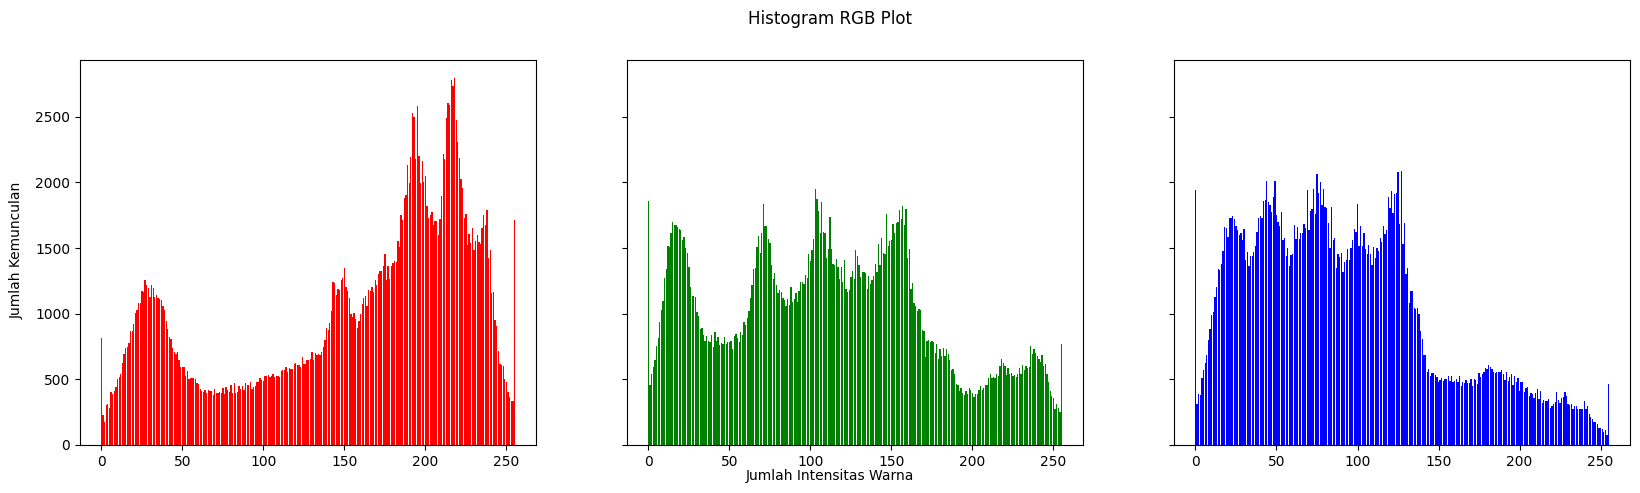

In [9]:
img = cv.imread(DIR + '/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range (0,height):
  for x in range (0, width):
    red[img[y][x][0]] += 1
    green [img[y][x][1]] += 1
    blue[img[y][x][2]] += 1


names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=(20, 5), sharex=True, sharey=True)
fig.suptitle('Histogram RGB Plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Jumlah Intensitas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')

<BarContainer object of 256 artists>

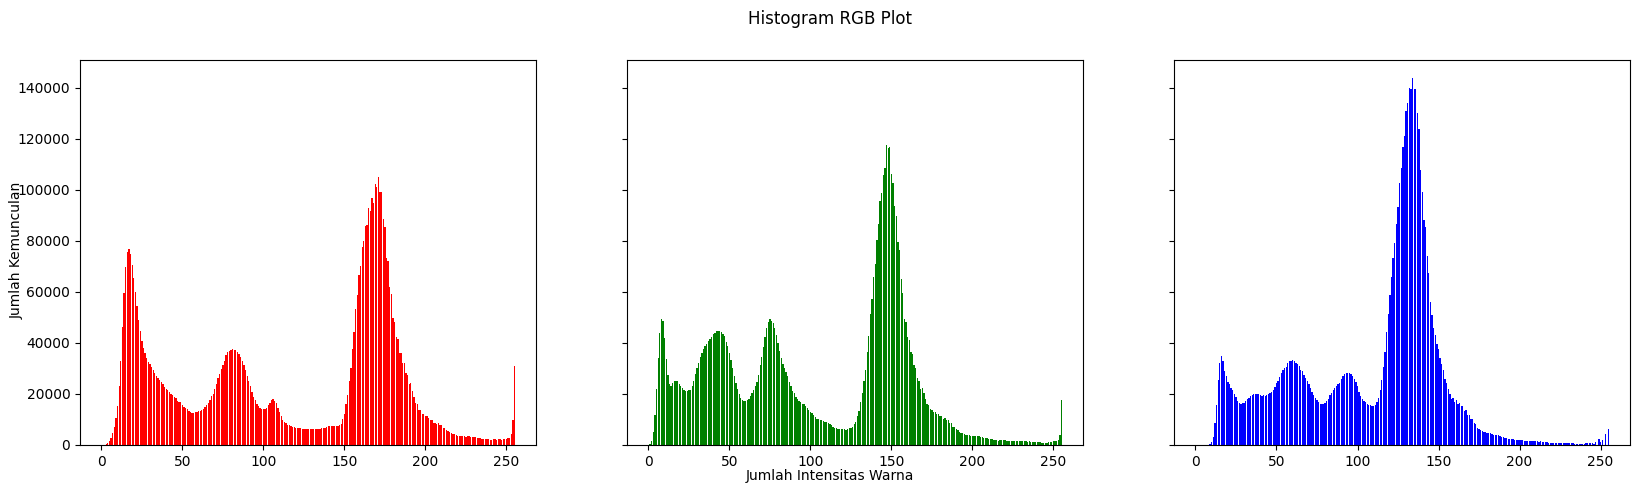

In [10]:
img = cv.imread(DIR + '/KTM1b.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range (0,height):
  for x in range (0, width):
    red[img[y][x][0]] += 1
    green [img[y][x][1]] += 1
    blue[img[y][x][2]] += 1


names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=(20, 5), sharex=True, sharey=True)
fig.suptitle('Histogram RGB Plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Jumlah Intensitas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')

##**Pertanyaan Praktikum E-1**


1. Buatlah histogram citra yang sama menggunakan library NumPy, yaitu
numpy.histogram, dan juga cv.calcHist. Bandingkan ketiganya dengan menghitung
selisih maksimum antar hasil. Selisihnya harus nol; tampilkan pembuktiannya pada
lena.jpg lebih dulu, kemudian ulangi pada KTM1b.jpg.

In [5]:
def histogram_manual(img):
    histogram = np.zeros(256, dtype=np.int64)

    for nilai in img.ravel():
        histogram[nilai] += 1

    return histogram

def cek_histogram(file_gambar):
    image = cv.imread(file_gambar)

    if image is None:
        print('Gambar tidak ditemukan')
        return

    kanal = {
        'Biru': image[:, :, 0],
        'Hijau': image[:, :, 1],
        'Merah': image[:, :, 2]
    }

    for nama, data in kanal.items():
        manual = histogram_manual(data)
        numpy_histogram, _ = np.histogram(data,bins=256,range=(0, 256))
        opencv_histogram = cv.calcHist([data],[0],None,[256],[0, 256]).reshape(256).astype(np.int64)
        beda_numpy = np.max(np.abs(manual - numpy_histogram))
        beda_opencv = np.max(np.abs(manual - opencv_histogram))
        print(nama,'| Manual-NumPy:',beda_numpy,'| Manual-OpenCV:',beda_opencv)

print('Hasil lena.jpg')
cek_histogram(DIR + '/lena.jpg')

print('\nHasil KTM1b.jpg')
cek_histogram(DIR + '/KTM1b.jpg')

Hasil lena.jpg
Biru | Manual-NumPy: 0 | Manual-OpenCV: 0
Hijau | Manual-NumPy: 0 | Manual-OpenCV: 0
Merah | Manual-NumPy: 0 | Manual-OpenCV: 0

Hasil KTM1b.jpg
Biru | Manual-NumPy: 0 | Manual-OpenCV: 0
Hijau | Manual-NumPy: 0 | Manual-OpenCV: 0
Merah | Manual-NumPy: 0 | Manual-OpenCV: 0


  2.  Gambarkan histogram ternormalisasi p(j) dan kurva CDF untuk KTM1a.jpg sampai
KTM1d.jpg dalam satu figure 2 x 2. Jelaskan perbedaan bentuk kurva CDF antara citra
paling gelap dan citra paling terang milik Anda, lalu kaitkan dengan kondisi
pencahayaan saat akuisisi pada Pertemuan 2.

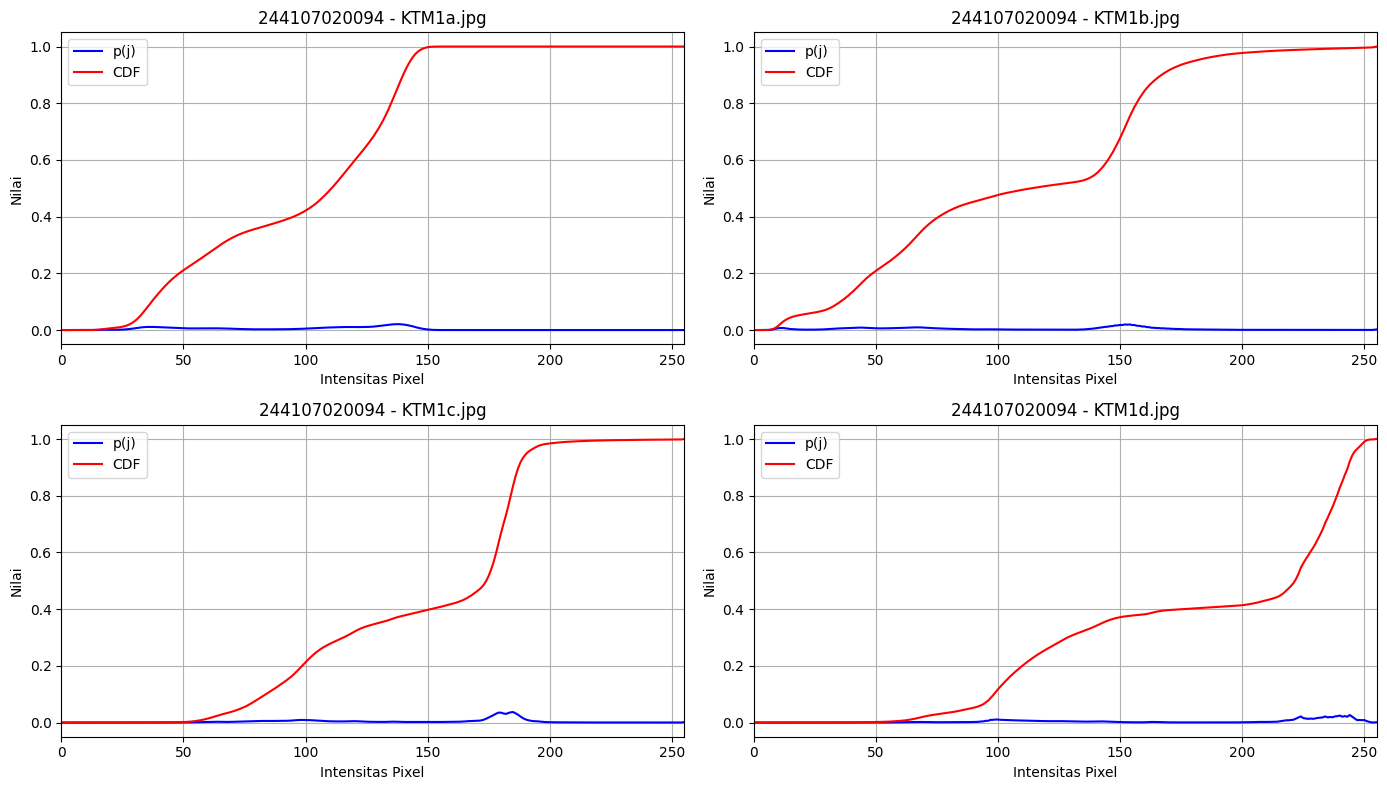

In [7]:
def histogram_manual(img):
    h = np.zeros(256, dtype=np.int64)

    for nilai in img.ravel():
        h[nilai] += 1

    return h

nama_file = ['KTM1a.jpg', 'KTM1b.jpg', 'KTM1c.jpg', 'KTM1d.jpg']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, nama in zip(axes.ravel(), nama_file):
    gray = cv.imread(
        DIR + '/' + nama,
        cv.IMREAD_GRAYSCALE
    )

    h = histogram_manual(gray)
    p = h / gray.size
    cdf = np.cumsum(p)

    ax.plot(p, color='blue', label='p(j)')
    ax.plot(cdf, color='red', label='CDF')
    ax.set_title(NIM + ' - ' + nama)
    ax.set_xlabel('Intensitas Pixel')
    ax.set_ylabel('Nilai')
    ax.set_xlim(0, 255)
    ax.grid()
    ax.legend()

plt.tight_layout()
plt.show()

3. Ulangi histogram KTM1b.jpg dengan jumlah bin sebesar PARAM['bins'] dan dengan
256 bin. Tampilkan keduanya berdampingan dan jelaskan informasi apa yang hilang
ketika jumlah bin dikurangi.

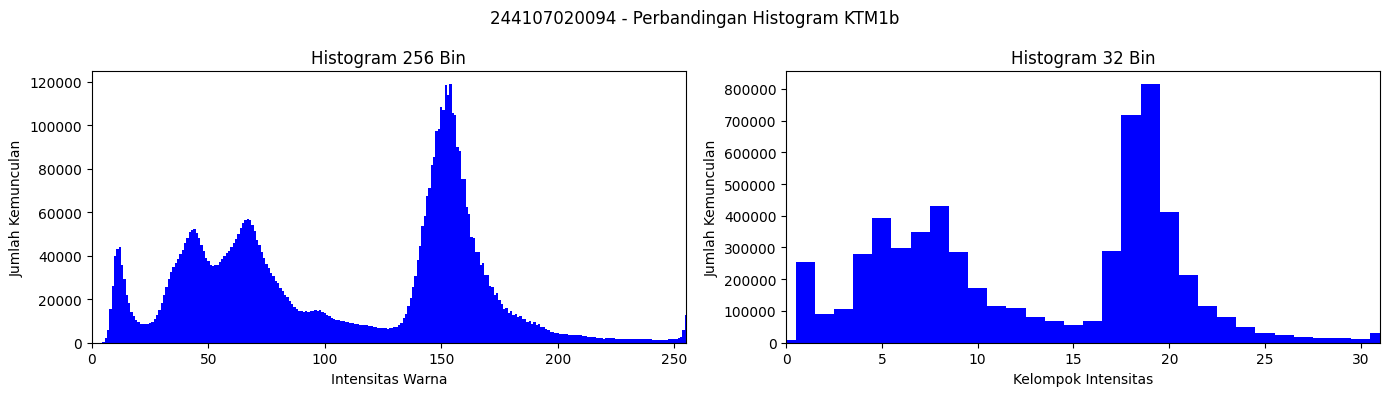

In [19]:
gray = cv.imread(DIR + '/KTM1b.jpg',cv.IMREAD_GRAYSCALE)

hist_256, _ = np.histogram(gray,bins=256,range=(0, 256))

hist_32, _ = np.histogram(gray,bins=32,range=(0, 256))

fig, axs = plt.subplots(1, 2, figsize=(14, 4))

fig.suptitle(NIM + ' - Perbandingan Histogram KTM1b')

axs[0].bar(np.arange(256),hist_256,color='blue',width=1)
axs[0].set_title('Histogram 256 Bin')
axs[0].set_xlabel('Intensitas Warna')
axs[0].set_ylabel('Jumlah Kemunculan')
axs[0].set_xlim(0, 255)

axs[1].bar(np.arange(32),hist_32,color='blue',width=1)
axs[1].set_title('Histogram 32 Bin')
axs[1].set_xlabel('Kelompok Intensitas')
axs[1].set_ylabel('Jumlah Kemunculan')
axs[1].set_xlim(0, 31)

plt.tight_layout()
plt.show()

#**E-2 PERCOBAAN HISTOGRAM EQUALIZATION**

1. Buatlah histogram equalization beserta tampilan citra sebelum dan sesudah proses,
berdasarkan flowchart di bawah ini. Tahap 1 gunakan citra contoh lena_lc.jpg dan
cocokkan hasilnya dengan gambar contoh pada modul; tahap 2 ulangi pada citra
KTM1a.jpg milik Anda, yaitu hasil akuisisi di ruangan gelap.

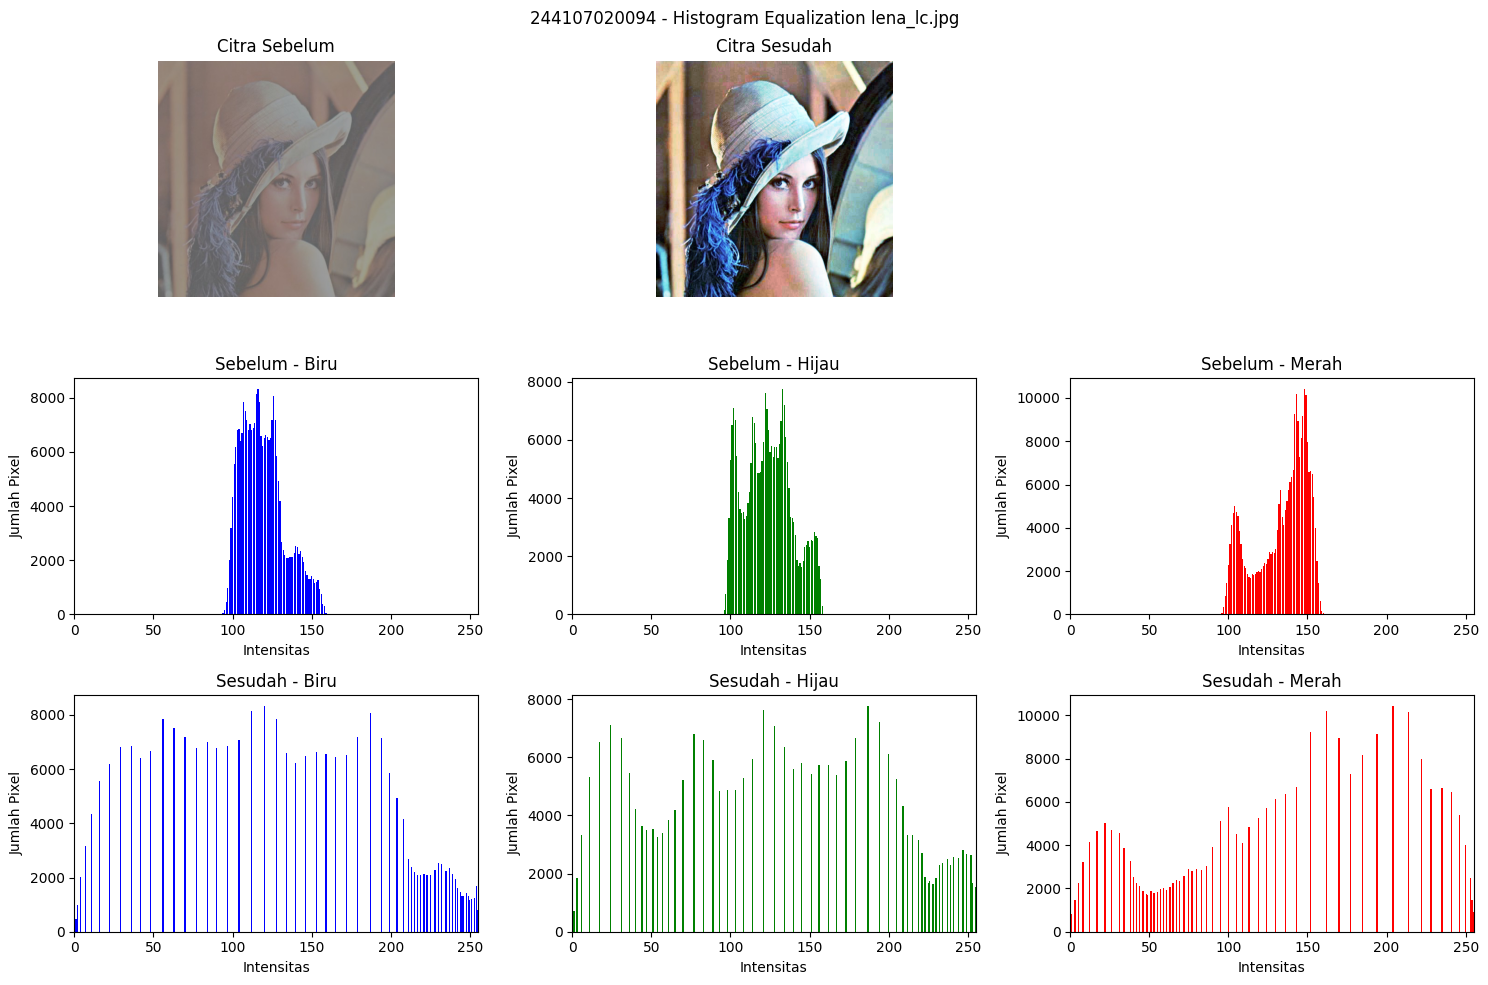

In [63]:
def histogram_manual(img, L=256):
    h = np.zeros(L, dtype=np.int64)

    for y in range(img.shape[0]):
        for x in range(img.shape[1]):
            h[img[y, x]] += 1

    return h

# Histogram equalization manual
def equalize(channel):
    h = histogram_manual(channel)
    p = h / channel.size
    cdf = np.cumsum(p)
    tabel = np.round(cdf * 255).astype(np.uint8)

    return tabel[channel]

# File citra
nama_file = 'lena_lc.jpg'

# Membaca citra
bgr = cv.imread(
    DIR + '/lena_lc.jpg'
)

# Memisahkan channel B, G, dan R
kanal_asli = cv.split(bgr)

# Melakukan equalization pada setiap channel
kanal_hasil = [
    equalize(kanal_asli[0]),
    equalize(kanal_asli[1]),
    equalize(kanal_asli[2])
]

# Menggabungkan channel hasil equalization
hasil = cv.merge(kanal_hasil)

# Warna histogram
warna = ['blue', 'green', 'red']
nama_channel = ['Biru', 'Hijau', 'Merah']

# Menampilkan citra dan histogram
fig, axs = plt.subplots(3, 3, figsize=(15, 10))

fig.suptitle(
    NIM + ' - Histogram Equalization ' + nama_file
)

# Citra sebelum
axs[0, 0].imshow(
    cv.cvtColor(bgr, cv.COLOR_BGR2RGB)
)
axs[0, 0].set_title('Citra Sebelum')
axs[0, 0].axis('off')

# Citra sesudah
axs[0, 1].imshow(
    cv.cvtColor(hasil, cv.COLOR_BGR2RGB)
)
axs[0, 1].set_title('Citra Sesudah')
axs[0, 1].axis('off')

# Mengosongkan subplot ketiga
axs[0, 2].axis('off')

# Histogram sebelum
for i in range(3):
    hist_asli = histogram_manual(kanal_asli[i])

    axs[1, i].bar(
        range(256),
        hist_asli,
        color=warna[i]
    )
    axs[1, i].set_title(
        'Sebelum - ' + nama_channel[i]
    )
    axs[1, i].set_xlabel('Intensitas')
    axs[1, i].set_ylabel('Jumlah Pixel')
    axs[1, i].set_xlim(0, 255)

# Histogram sesudah
for i in range(3):
    hist_hasil = histogram_manual(kanal_hasil[i])

    axs[2, i].bar(
        range(256),
        hist_hasil,
        color=warna[i]
    )
    axs[2, i].set_title(
        'Sesudah - ' + nama_channel[i]
    )
    axs[2, i].set_xlabel('Intensitas')
    axs[2, i].set_ylabel('Jumlah Pixel')
    axs[2, i].set_xlim(0, 255)

plt.tight_layout()
plt.show()

In [62]:
def histogram_manual(img, L=256):
    h = np.zeros(L, dtype=np.int64)

    for y in range(img.shape[0]):
        for x in range(img.shape[1]):
            h[img[y, x]] += 1

    return h

# Histogram equalization manual
def equalize(channel):
    h = histogram_manual(channel)
    p = h / channel.size
    cdf = np.cumsum(p)
    tabel = np.round(cdf * 255).astype(np.uint8)

    return tabel[channel]

# File citra
nama_file = 'KTM1a.jph'

# Membaca citra
bgr = cv.imread(DIR + nama_file  )

# Memisahkan channel B, G, dan R
kanal_asli = cv.split(bgr)

# Melakukan equalization pada setiap channel
kanal_hasil = [equalize(kanal_asli[0]),equalize(kanal_asli[1]),equalize(kanal_asli[2])]

# Menggabungkan channel hasil equalization
hasil = cv.merge(kanal_hasil)

# Warna histogram
warna = ['blue', 'green', 'red']
nama_channel = ['Biru', 'Hijau', 'Merah']

# Menampilkan citra dan histogram
fig, axs = plt.subplots(3, 3, figsize=(15, 10))

fig.suptitle(NIM + ' - Histogram Equalization ' + nama_file)

# Citra sebelum
axs[0, 0].imshow(cv.cvtColor(bgr, cv.COLOR_BGR2RGB))
axs[0, 0].set_title('Citra Sebelum')
axs[0, 0].axis('off')

# Citra sesudah
axs[0, 1].imshow(cv.cvtColor(hasil, cv.COLOR_BGR2RGB))
axs[0, 1].set_title('Citra Sesudah')
axs[0, 1].axis('off')
axs[0, 2].axis('off')

# Histogram sebelum
for i in range(3):
    hist_asli = histogram_manual(kanal_asli[i])

    axs[1, i].bar(range(256),hist_asli,color=warna[i])
    axs[1, i].set_title('Sebelum - ' + nama_channel[i])
    axs[1, i].set_xlabel('Intensitas')
    axs[1, i].set_ylabel('Jumlah Pixel')
    axs[1, i].set_xlim(0, 255)

# Histogram sesudah
for i in range(3):
    hist_hasil = histogram_manual(kanal_hasil[i])
    axs[2, i].bar(range(256),hist_hasil,color=warna[i])
    axs[2, i].set_title(
        'Sesudah - ' + nama_channel[i]
    )
    axs[2, i].set_xlabel('Intensitas')
    axs[2, i].set_ylabel('Jumlah Pixel')
    axs[2, i].set_xlim(0, 255)

plt.tight_layout()
plt.show()

IndexError: tuple index out of range

2/ Setelah mengerjakan langkah no. 1, buatlah histogram citra yang sama akan tetapi
menggunakan library yang dimiliki oleh CV2 yaitu “equalizeHist”.Lengkapi potongan kode tersebut. Bandingkan hasil equalizeHist dengan hasil
implementasi manual Anda dengan menghitung selisih maksimum antara keduanya,
baik pada lena_lc.jpg maupun pada KTM1a.jpg, lalu jelaskan penyebab selisih tersebut
apabila tidak nol.

In [65]:
def equalize_manual_bgr(bgr):
    b, g, r = cv.split(bgr)

    return cv.merge([
        equalize(b),
        equalize(g),
        equalize(r)
    ])

def bandingkan_equalize(path_gambar, nama_file):
    bgr = cv.imread(path_gambar)
    hasil_manual = equalize_manual_bgr(bgr)

    b, g, r = cv.split(bgr)
    hasil_cv = cv.merge([cv.equalizeHist(b),cv.equalizeHist(g),cv.equalizeHist(r)])

    selisih = np.max(
        np.abs(
            hasil_manual.astype(int)
            - hasil_cv.astype(int)
        )
    )

    print(f'{nama_file}: 'f'selisih maksimum manual vs 'f'cv.equalizeHist = {selisih}')
bandingkan_equalize(DIR + '/lena_lc.jpg','lena_lc.jpg')
bandingkan_equalize(DIR + '/KTM1a.jpg','KTM1a.jpg')

lena_lc.jpg: selisih maksimum manual vs cv.equalizeHist = 0
KTM1a.jpg: selisih maksimum manual vs cv.equalizeHist = 0


Berdasarkan hasil pengujian, selisih maksimum antara histogram equalization manual dan cv.equalizeHist() adalah 0 pada kedua citra. Hal ini menunjukkan bahwa hasil transformasi manual dan library OpenCV menghasilkan nilai pixel yang sama. Dengan demikian, implementasi rumus histogram equalization yang dibuat sudah sesuai dengan hasil cv.equalizeHist().

3. Ekualisasi juga dapat diterapkan pada citra berwarna. Cara yang biasanya pertama kali
terpikirkan adalah mengekualisasi kanal biru, hijau, dan merah satu per satu. Jalankan
potongan kode berikut pada citra contoh lena.jpg terlebih dulu, kemudian ulangi pada
KTM1d.jpg milik Anda, dan amati warna yang dihasilkan pada keduanya.

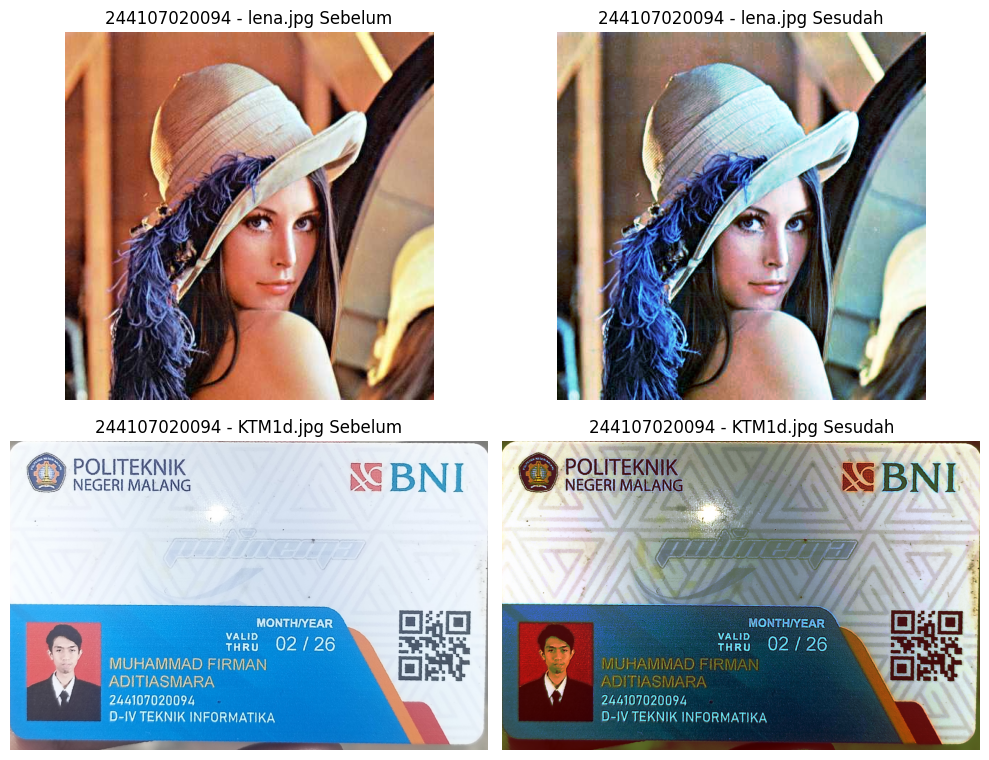

In [68]:
berkas = ['lena.jpg', 'KTM1d.jpg']

fig, axs = plt.subplots(2, 2, figsize=(10, 8))

for i, nama_file in enumerate(berkas):
    bgr = cv.imread(DIR + '/' + nama_file)

    kanal = list(cv.split(bgr))

    for j in range(3):
        kanal[j] = cv.equalizeHist(kanal[j])

    he_rgb = cv.merge(kanal)

    axs[i, 0].imshow(cv.cvtColor(bgr, cv.COLOR_BGR2RGB))
    axs[i, 0].set_title(NIM + ' - ' + nama_file + ' Sebelum')
    axs[i, 0].axis('off')

    axs[i, 1].imshow(cv.cvtColor(he_rgb, cv.COLOR_BGR2RGB))
    axs[i, 1].set_title(NIM + ' - ' + nama_file + ' Sesudah')
    axs[i, 1].axis('off')

plt.tight_layout()
plt.show()

Pada kedua citra, warna hasil equalization kanal B, G, dan R secara terpisah dapat berubah dari warna aslinya. Hal ini terjadi karena setiap kanal memiliki distribusi histogram yang berbeda, sehingga masing-masing kanal mengalami perubahan intensitas yang berbeda pula.

4. Cara kedua memisahkan kecerahan dari informasi warna. Citra diubah ke ruang warna
YCrCb, hanya kanal Y yang diekualisasi, lalu dikembalikan ke BGR. Kanal Cr dan Cb yang
menyimpan informasi warna tidak disentuh sama sekali. Kanal V pada HSV dan kanal
L pada LAB berperan serupa, sehingga ketiganya dicoba sekaligus. (gunakan
KTM1d.jpg)

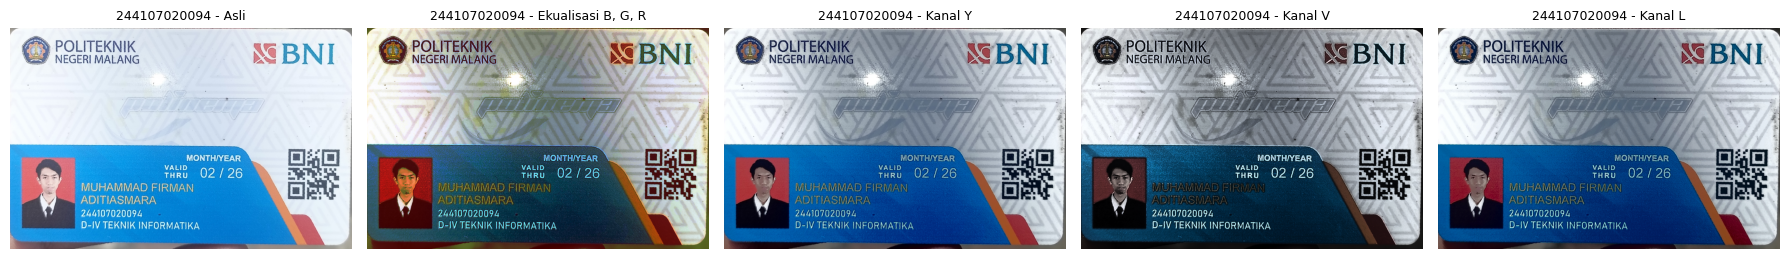

Cara                        Geser Hue    Rerata Terang
Asli                             0.00            184.7
Ekualisasi B, G, R              55.65            127.7
Kanal Y                          2.42            132.7
Kanal V                          2.14            114.4
Kanal L                          4.79            123.0


In [44]:
bgr = cv.imread(DIR + '/KTM1d.jpg')

# Equalisasi kanal B, G, R
kanal = list(cv.split(bgr))

for i in range(3):
    kanal[i] = cv.equalizeHist(kanal[i])

he_rgb = cv.merge(kanal)

# Equalisasi kanal Y pada YCrCb
ycrcb = cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb)
y, cr, cb = cv.split(ycrcb)

he_y = cv.cvtColor(cv.merge([cv.equalizeHist(y), cr, cb]),cv.COLOR_YCrCb2BGR)

# Equalisasi kanal V pada HSV
hsv = cv.cvtColor(bgr, cv.COLOR_BGR2HSV)
h, sat, v = cv.split(hsv)

he_v = cv.cvtColor(cv.merge([h, sat, cv.equalizeHist(v)]),cv.COLOR_HSV2BGR)

# Equalisasi kanal L pada LAB
lab = cv.cvtColor(bgr, cv.COLOR_BGR2LAB)
l, a, b = cv.split(lab)

he_l = cv.cvtColor(cv.merge([cv.equalizeHist(l), a, b]),cv.COLOR_LAB2BGR)

# Menampilkan kelima citra
judul = [
    'Asli',
    'Ekualisasi B, G, R',
    'Kanal Y',
    'Kanal V',
    'Kanal L'
]

citra = [bgr, he_rgb, he_y, he_v, he_l]

plt.figure(figsize=(18, 4))

for i, (gambar, nama) in enumerate(zip(citra, judul),start=1):
    plt.subplot(1, 5, i)
    plt.imshow(cv.cvtColor(gambar, cv.COLOR_BGR2RGB))
    plt.title(NIM + ' - ' + nama, fontsize=9)
    plt.axis('off')

plt.tight_layout()
plt.show()

def geser_hue(asli, hasil):
    h1 = cv.cvtColor(asli,cv.COLOR_BGR2HSV)[:, 0].astype(np.int16)

    h2 = cv.cvtColor(hasil,cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)

    selisih = np.abs(h1 - h2)
    selisih = np.minimum(selisih, 180 - selisih)

    return selisih.mean() * 2

print(f'{"Cara":<24} {"Geser Hue":>12} {"Rerata Terang":>16}')

for nama, gambar in zip(judul, citra):
    terang = cv.cvtColor(
        gambar,
        cv.COLOR_BGR2GRAY
    ).mean()

    print(
        f'{nama:<24} '
        f'{geser_hue(bgr, gambar):>12.2f} '
        f'{terang:>16.1f}'
    )

Jawab pertanyaan berikut berdasarkan angka pada tabel Anda, bukan hanya dari pengamatan mata:
1. Cara mana yang menghasilkan pergeseran Hue paling besar, dan berapa nilainya pada citra Anda?
      
    **Jawab**: Metode ekualisasi kanal B, G, dan R menghasilkan pergeseran Hue paling besar, yaitu 55,65 Hal ini terjadi karena kanal biru, hijau, dan merah diproses secara terpisah. Perubahan setiap kanal tidak sama, sehingga keseimbangan warna citra berubah cukup besar.
2. Mengapa ekualisasi kanal terang tetap menghasilkan pergeseran Hue yang tidak persis
nol? Kaitkan jawaban Anda dengan pembulatan dan pemotongan nilai ketika citra
dikembalikan ke ruang warna BGR.

    **Jawab:** Citra dikonversi kembali dari YCrCb, HSV, atau LAB ke BGR.,  Proses konversi ruang warna menyebabkan sedikit perubahan nilai pada setiap channel.Nilai pixel yang keluar dari rentang 0-255 dipotong atau di-clip. Akibatnya, nilai Hue dapat berubah sedikit walaupun channel warna tidak diekualisasi
3. Di antara kanal Y, V, dan L, mana yang paling sesuai untuk foto KTM Anda? Sebutkan alasannya dan tunjukkan bagian citra yang menjadi dasar penilaian.

    **Jawab**: Untuk foto KTM, metode yang paling seimbang adalah kanal Y pada YCrCb, karena:
    - Pergeseran Hue tetap kecil.
    - Rata-rata kecerahan lebih tinggi daripada kanal V dan L.
    - Detail pada area gelap, terutama bagian nama dan NIM di bagian bawah kartu, lebih terbantu.
    - Warna kartu tidak berubah sebesar metode ekualisasi kanal B, G, dan R.
    
    Bagian citra yang menjadi dasar penilaian adalah area bawah kartu yang berisi foto, nama, NIM, dan kelas, karena area tersebut memiliki detail gelap yang perlu dibuat lebih terbaca.
    
4. Ulangi salah satu cara pada kanal terang dengan mengganti cv.equalizeHist menjadi
CLAHE yang memakai clipLimit = PARAM['clip'] dan tileGridSize = (PARAM['tile'],
PARAM['tile']). Bandingkan pergeseran Hue dan rerata kecerahannya dengan hasil
ekualisasi biasa.

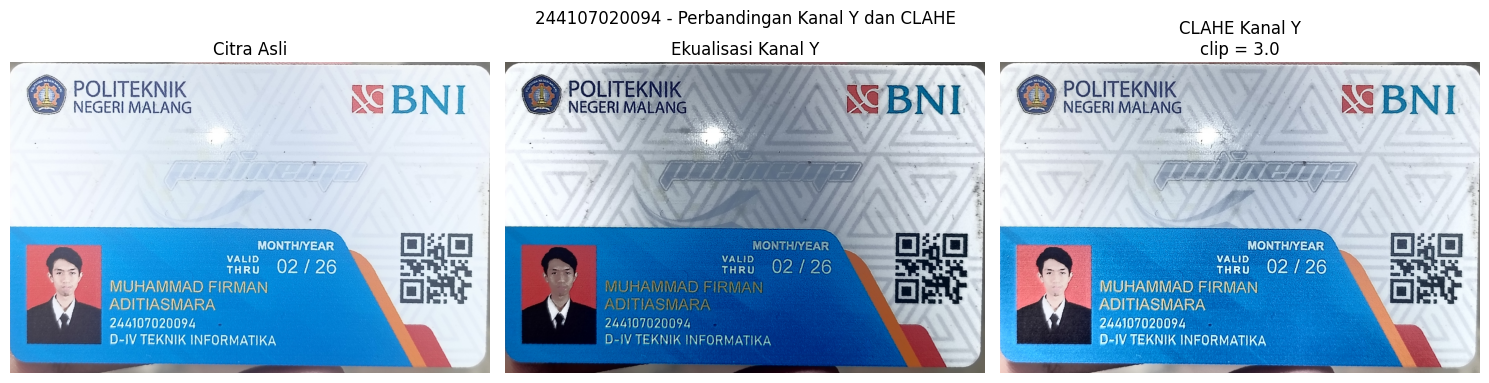

Ekualisasi Kanal Y
Geser Hue       : 2.42 derajat
Rerata kecerahan: 132.7

CLAHE Kanal Y
Geser Hue       : 0.44 derajat
Rerata kecerahan: 167.9


In [70]:
# CLAHE pada kanal Y
ycrcb = cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb)
y, cr, cb = cv.split(ycrcb)

clahe = cv.createCLAHE(
    clipLimit=PARAM['clip'],
    tileGridSize=(PARAM['tile'], PARAM['tile'])
)

hasil_clahe = cv.cvtColor(
    cv.merge([clahe.apply(y), cr, cb]),
    cv.COLOR_YCrCb2BGR
)

# Menampilkan gambar
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

axs[0].imshow(cv.cvtColor(bgr, cv.COLOR_BGR2RGB))
axs[0].set_title('Citra Asli')
axs[0].axis('off')

axs[1].imshow(cv.cvtColor(he_y, cv.COLOR_BGR2RGB))
axs[1].set_title('Ekualisasi Kanal Y')
axs[1].axis('off')

axs[2].imshow(cv.cvtColor(hasil_clahe, cv.COLOR_BGR2RGB))
axs[2].set_title(
    'CLAHE Kanal Y\n'
    + 'clip = ' + str(PARAM['clip'])
)
axs[2].axis('off')

plt.suptitle(NIM + ' - Perbandingan Kanal Y dan CLAHE')
plt.tight_layout()
plt.show()

# Menghitung nilai pergeseran Hue dan kecerahan
print('Ekualisasi Kanal Y')
print('Geser Hue       :', round(geser_hue(bgr, he_y), 2), 'derajat')
print('Rerata kecerahan:', round(
    cv.cvtColor(he_y, cv.COLOR_BGR2GRAY).mean(), 1
))

print('\nCLAHE Kanal Y')
print('Geser Hue       :', round(geser_hue(bgr, hasil_clahe), 2), 'derajat')
print('Rerata kecerahan:', round(
    cv.cvtColor(hasil_clahe, cv.COLOR_BGR2GRAY).mean(), 1
))

Ekualisasi kanal Y dan CLAHE sama-sama meningkatkan kontras citra, tetapi CLAHE bekerja secara lokal sehingga detail pada bagian gelap dapat terlihat lebih merata.

##**Pertanyaan Praktikum E-2**

1. Ekualisasi global pada citra KTM Anda

    a. Terapkan ekualisasi manual dan cv.equalizeHist pada KTM1a.jpg versiv grayscale.

    b. Tampilkan citra asli, citra hasil ekualisasi, serta histogram dalam satu layout.

    c. Hitung PSNR antara citra asli dan citra hasil ekualisasi. Jelaskan mengapa nilai

PSNR justru turun padahal citra terlihat lebih jelas, lalu simpulkan apakah PSNR
layak dipakai untuk menilai keterbacaan sebuah citra.

In [58]:
def histogram_manual(img):
    h = np.zeros(256, dtype=np.int64)

    for nilai in img.ravel():
        h[nilai] += 1

    return h
def equalize_manual_channel(channel):
    h = histogram_manual(channel)
    p = h / channel.size
    cdf = np.cumsum(p)
    tabel = np.round(cdf * 255).astype(np.uint8)

    return tabel[channel]

PSNR Manual: 14.42 dB
PSNR OpenCV: 14.42 dB


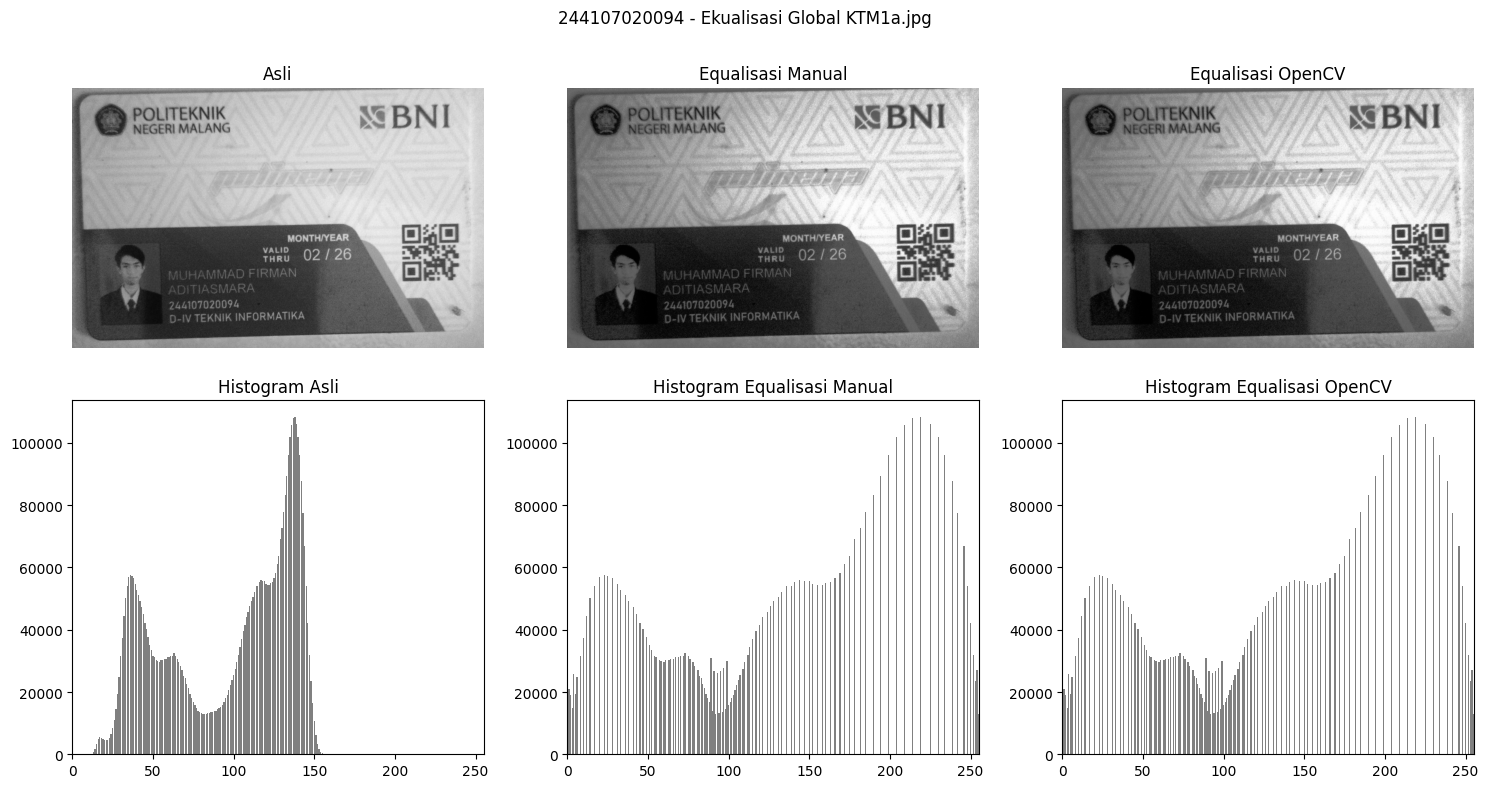

In [61]:
def hitung_psnr(asli, hasil):
    mse = np.mean((asli.astype(float) - hasil.astype(float)) ** 2)
    return float('inf') if mse == 0 else 10 * np.log10(255**2 / mse)

gray = cv.imread(DIR + '/KTM1a.jpg',cv.IMREAD_GRAYSCALE)

manual = equalize_manual_channel(gray)
opencv = cv.equalizeHist(gray)

print('PSNR Manual:',round(hitung_psnr(gray, manual), 2), 'dB')

print('PSNR OpenCV:',round(hitung_psnr(gray, opencv), 2), 'dB')

citra = [gray, manual, opencv]
judul = ['Asli', 'Equalisasi Manual', 'Equalisasi OpenCV']

fig, axs = plt.subplots(2, 3, figsize=(15, 8))

for i in range(3):
    axs[0, i].imshow(citra[i], cmap='gray')
    axs[0, i].set_title(judul[i])
    axs[0, i].axis('off')

    axs[1, i].bar(range(256),histogram_manual(citra[i]),color='gray')
    axs[1, i].set_title('Histogram ' + judul[i])
    axs[1, i].set_xlim(0, 255)

fig.suptitle(NIM + ' - Ekualisasi Global KTM1a.jpg')
plt.tight_layout()
plt.show()

Histogram equalization berhasil meningkatkan kontras citra KTM1a.jpg. Hasil equalization manual dan cv.equalizeHist() memiliki tampilan serta histogram yang hampir sama, sehingga implementasi manual dapat dianggap sesuai. Nilai PSNR yang lebih rendah tidak berarti citra hasil lebih buruk, karena proses equalization memang mengubah intensitas pixel untuk meningkatkan kontras. Jika berdasarkan praktikum saya Nilai PSNR hasil ekualisasi manual dan cv.equalizeHist() sama-sama sebesar 14,42 dB. Hal ini menunjukkan bahwa kedua metode menghasilkan perubahan nilai pixel yang sama atau sangat dekat terhadap citra asli.

Hasil ini menunjukkan bahwa PSNR tidak dapat digunakan sebagai satu-satunya ukuran untuk menilai keterbacaan citra. PSNR hanya mengukur kemiripan nilai pixel secara numerik, bukan kejelasan tulisan atau detail visual.

2. Ekualisasi lokal dengan CLAHE pada citra KTM Anda
    a. Terapkan CLAHE pada KTM1a.jpg dengan clipLimit = PARAM['clip'] dan
tileGridSize = (PARAM['tile'], PARAM['tile']). Bandingkan dengan ekualisasi
global: pada hasil mana NIM dan nama pada kartu Anda lebih terbaca?

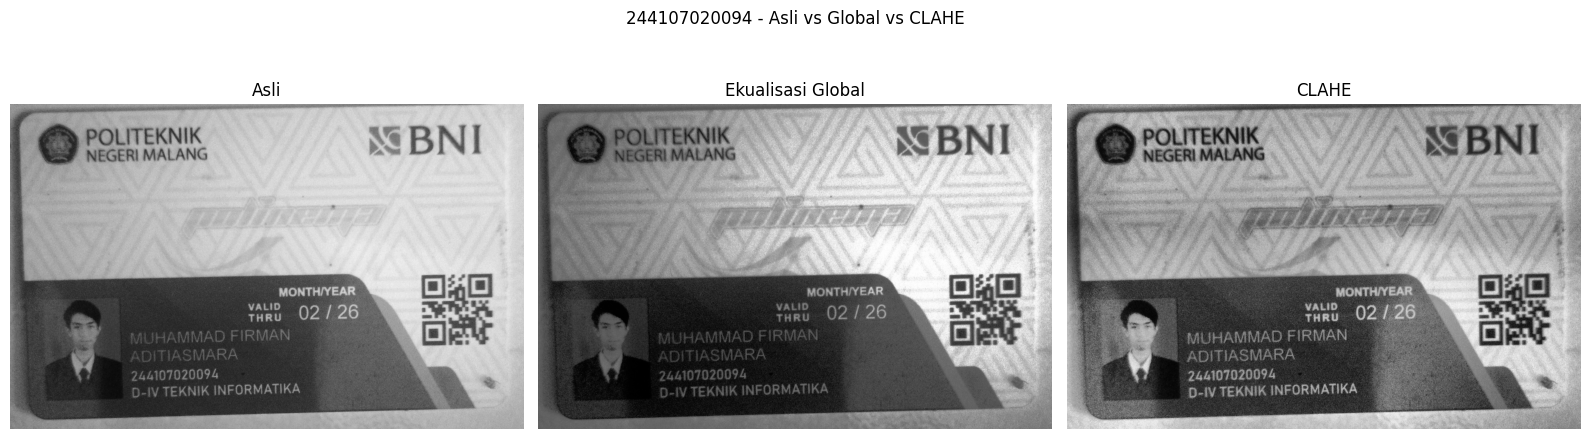

In [72]:
clahe_a = cv.createCLAHE(clipLimit=PARAM['clip'],tileGridSize=(PARAM['tile'], PARAM['tile']))
hasil_clahe_a = clahe_a.apply(gray_a)
fig, axs = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(NIM + ' - Asli vs Global vs CLAHE')

axs[0].imshow(gray_a, cmap='gray')
axs[0].set_title('Asli')
axs[0].axis('off')

axs[1].imshow(hasil_cv_a, cmap='gray')
axs[1].set_title('Ekualisasi Global')
axs[1].axis('off')

axs[2].imshow(hasil_clahe_a, cmap='gray')
axs[2].set_title('CLAHE')
axs[2].axis('off')

plt.tight_layout()
plt.show()

Pada hasil CLAHE, peningkatan kontras dilakukan secara lokal sehingga area kartu yang gelap menjadi lebih jelas. Nama dan NIM pada kartu terlihat lebih terbaca. Oleh karena itu, CLAHE dipilih sebagai metode yang membuat NIM dan nama pada kartu lebih terbaca

 b. Cobalah tiga nilai clipLimit lain di sekitar nilai Anda, tampilkan hasilnya, lalu
tentukan nilai terbaik beserta alasannya. Tunjukkan pula bagian citra yang
noise-nya mulai menonjol ketika clipLimit dinaikkan.

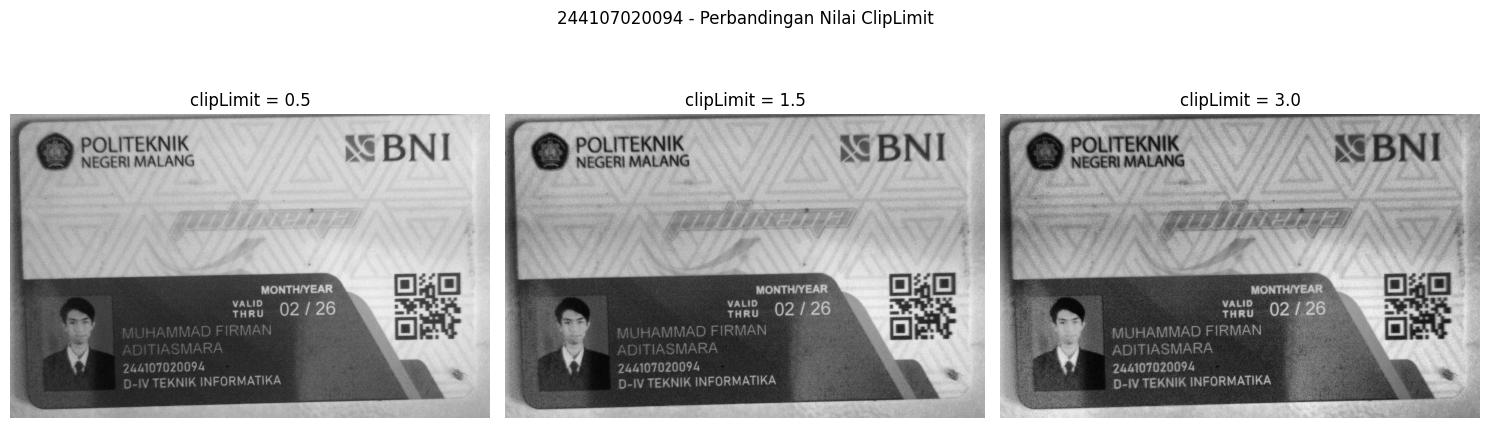

In [78]:
clip_values = [0.5, 1.5, 3.0]

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(NIM + ' - Perbandingan Nilai ClipLimit')

for ax, clip in zip(axs, clip_values):
    clahe = cv.createCLAHE(
        clipLimit=clip,
        tileGridSize=(PARAM['tile'], PARAM['tile'])
    )

    hasil = clahe.apply(gray_a)

    ax.imshow(hasil, cmap='gray')
    ax.set_title('clipLimit = ' + str(clip))
    ax.axis('off')

plt.tight_layout()
plt.show()

Pada clipLimit = 0.5, peningkatan kontras masih rendah. Pada clipLimit = 1.5, kontras mulai meningkat dan tulisan menjadi lebih terbaca dengan noise yang masih sedikit. Pada clipLimit = 3.0, kontras lebih kuat sehingga detail nama dan NIM dapat terlihat lebih jelas namun pada bagian gamber yang gelap muncul banyak noise

#**E-3 Tugas Praktikum Dithering**